In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)


In [2]:
type(data)

dict

In [3]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,minted_market_cap,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12584,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,2.000158e+07,2.000158e+07,False,1.450651e+12,NaN,1,NaN,NaN,None,2026-03-13T10:44:00.000Z,72526.840176,4.891526e+10,4.885482e+10,6.044407e+07,9.8121,0.907969,3.043750,2.808683,8.729853,-19.781081,-19.957219,1.450651e+12,58.9789,1.523064e+12,None,2026-03-13T10:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:07.477230
1,1027,Ethereum,ETH,ethereum,11631,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.206920e+08,1.206920e+08,True,2.568028e+11,NaN,2,NaN,NaN,None,2026-03-13T10:44:00.000Z,2127.753695,2.453811e+10,2.435379e+10,1.843197e+08,24.4405,0.996494,2.740791,3.108849,9.860360,-31.532830,-32.087975,2.568028e+11,10.4408,2.568028e+11,None,2026-03-13T10:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:07.477230
2,825,Tether USDt,USDT,tether,173853,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.839905e+11,1.889306e+11,True,1.889570e+11,NaN,3,NaN,NaN,None,2026-03-13T10:44:00.000Z,1.000140,9.461364e+10,9.240450e+10,2.209137e+09,12.8878,0.011184,0.007557,0.019066,0.065242,0.149407,0.007002,1.840162e+11,7.4815,1.889570e+11,None,2026-03-13T10:44:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-03-13 16:17:07.477230
3,1839,BNB,BNB,bnb,3156,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",1.363581e+08,1.363581e+08,1.363581e+08,False,9.103352e+10,NaN,4,NaN,NaN,None,2026-03-13T10:44:00.000Z,667.606059,1.889424e+09,1.820606e+09,6.881786e+07,11.1025,0.200407,2.378645,4.221411,13.481201,-25.760458,-25.231644,9.103352e+10,3.7011,9.103352e+10,None,2026-03-13T10:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:07.477230
4,52,XRP,XRP,xrp,1808,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,6.122783e+10,9.998570e+10,False,1.434043e+11,NaN,5,NaN,NaN,None,2026-03-13T10:44:00.000Z,1.434248,2.920157e+09,2.918257e+09,1.899839e+06,23.2562,0.315864,3.315278,2.081640,5.501759,-29.644378,-29.649522,8.781590e+10,3.5703,1.434248e+11,None,2026-03-13T10:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:07.477230
5,3408,USDC,USDC,usd-coin,38012,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,7.886809e+10,7.886809e+10,False,7.886319e+10,NaN,6,6.090122e+10,6.089744e+10,None,2026-03-13T10:44:00.000Z,0.999938,1.361447e+10,1.071771e+10,2.896757e+09,17.0685,-0.005411,0.014528,0.001345,0.002877,0.021758,0.010842,7.886319e+10,3.2063,7.886319e+10,None,2026-03-13T10:44:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-03-13 16:17:07.477230
6,5426,Solana,SOL,solana,1102,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.712368e+08,6.222660e+08,True,5.597466e+10,NaN,7,5.252369e+08,4.724660e+10,None,2026-03-13T10:43:00.000Z,89.952936,4.848184e+09,4.848153e+09,3.119582e+04,20.4574,0.797114,3.433278,2.606227,11.601251,-35.508279,-32.973586,5.138443e+10,2.0891,5.597466e+10,None,2026-03-13T10:43:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:07.477230
7,1958,TRON,TRX,tron,1311,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.474761e+10,9.474761e+10

In [5]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
   }
    headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
   }

    session = Session()
    session.headers.update(headers)

    try:
        response = session.get(url, params=parameters)
        data = json.loads(response.text)
        #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
        print(e)


    df = pd.json_normalize(data['data'])
    df['timestamp'] = pd.to_datetime('now')
    df

    if not os.path.isfile(r'D:\CompanyTask\Automating using python\API.csv'):
        df.to_csv(r'D:\CompanyTask\Automating using python\API.csv', header='column_names')
    else:
        df.to_csv(r'D:\CompanyTask\Automating using python\API.csv', mode='a', header=False)
        
    


In [6]:
import os
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print("Completed Successfully")
    sleep(60)#for 1 minute
exit()

Completed Successfully


KeyboardInterrupt: 

In [7]:
df54=pd.read_csv(r'D:\CompanyTask\Automating using python\API.csv')
df54

,Unnamed: 0,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,minted_market_cap,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,12584,2010-07-13T00:00:00.000Z,"['mineable', 'pow', 'sha-256', 'store-of-value...",2.100000e+07,2.000155e+07,2.000155e+07,False,1.437725e+12,NaN,1,NaN,NaN,NaN,2026-03-13T09:46:00.000Z,71880.694341,4.798768e+10,4.792941e+10,5.827217e+07,13.0538,0.085093,2.226919,1.978034,7.724533,-20.773528,-20.577181,1.437725e+12,58.8931,1.509495e+12,NaN,2026-03-13T09:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 15:18:06.613304
1,1,1027,Ethereum,ETH,ethereum,11631,2015-08-07T00:00:00.000Z,"['pos', 'smart-contracts', 'ethereum-ecosystem...",NaN,1.206920e+08,1.206920e+08,True,2.544379e+11,NaN,2,NaN,NaN,NaN,2026-03-13T09:46:00.000Z,2108.159933,2.427231e+10,2.409027e+10,1.820469e+08,26.8546,0.139091,2.261847,2.661338,8.491222,-32.375893,-32.386130,2.544379e+11,10.4225,2.544379e+11,NaN,2026-03-13T09:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 15:18:06.613304
2,2,825,Tether USDt,USDT,tether,173834,2015-02-25T00:00:00.000Z,"['stablecoin', 'asset-backed-stablecoin', 'usd...",NaN,1.839905e+11,1.889306e+11,True,1.889407e+11,NaN,3,NaN,NaN,NaN,2026-03-13T09:46:00.000Z,1.000054,9.293384e+10,9.078300e+10,2.150842e+09,14.1479,0.002426,-0.006445,0.002631,0.040935,0.138734,-0.016604,1.840004e+11,7.5372,1.889407e+11,NaN,2026-03-13T09:46:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-03-13 15:18:06.613304
3,3,1839,BNB,BNB,bnb,3155,2017-07-25T00:00:00.000Z,"['marketplace', 'centralized-exchange', 'payme...",1.363581e+08,1.363581e+08,1.363581e+08,False,9.088392e+10,NaN,4,NaN,NaN,NaN,2026-03-13T09:46:00.000Z,666.508954,1.818963e+09,1.760570e+09,5.839310e+07,7.8256,-0.099255,2.622668,4.131662,11.960495,-26.010581,-25.040876,9.088392e+10,3.7229,9.088393e+10,NaN,2026-03-13T09:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 15:18:06.613304
4,4,52,XRP,XRP,xrp,1808,2013-08-04T00:00:00.000Z,"['medium-of-exchange', 'enterprise-solutions',...",1.000000e+11,6.122783e+10,9.998570e+10,False,1.429729e+11,NaN,5,NaN,NaN,NaN,2026-03-13T09:46:00.000Z,1.429933,2.872041e+09,2.870146e+09,1.895548e+06,22.2033,-0.009410,3.261430,2.568354,5.149364,-30.074224,-29.830520,8.755170e+10,3.5864,1.429933e+11,NaN,2026-03-13T09:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 15:18:06.613304
5,5,3408,USDC,USDC,usd-coin,38008,2018-10-08T00:00:00.000Z,"['medium-of-exchange', 'stablecoin', 'asset-ba...",NaN,7.887431e+10,7.887431e+10,False,7.887220e+10,NaN,6,6.090122e+10,6.089959e+10,NaN,2026-03-13T09:46:00.000Z,0.999973,1.343117e+10,1.057845e+10,2.852719e+09,15.3746,0.014907,0.001820,0.005641,-0.009107,0.021306,-0.005240,7.887220e+10,3.2308,7.887220e+10,NaN,2026-03-13T09:46:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-03-13 15:18:06.613304
6,6,5426,Solana,SOL,solana,1102,2020-04-10T00:00:00.000Z,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",NaN,5.712369e+08,6.222660e+08,True,5.557158e+10,NaN,7,5.252369e+08,4.690638e+10,NaN,2026-03-13T09:46:00.000Z,89.305185,4.797380e+09,4.797348e+09,3.198858e+04,20.0072,0.054190,3.435153,2.214740,10.309304,-36.150608,-33.218865,5.101441e+10,2.0897,5.557158e+10,NaN,2026-03-13T09:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 15:18:06.613304
7,7,1958,TRON,TRX,tron,1311,2017-09-13T00:00:00.000Z,"['media', 'payments', 'tron-ecosystem', 'layer...",NaN,9.47476

In [8]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,minted_market_cap,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12584,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,2.000158e+07,2.000158e+07,False,1.450370e+12,NaN,1,NaN,NaN,None,2026-03-13T10:45:00.000Z,72512.755095,4.891904e+10,4.885860e+10,6.044371e+07,9.8511,0.864284,3.021903,2.792866,8.678788,-19.784981,-19.959006,1.450370e+12,58.9675,1.522768e+12,None,2026-03-13T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:22.590653
1,1027,Ethereum,ETH,ethereum,11631,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.206920e+08,1.206920e+08,True,2.567885e+11,NaN,2,NaN,NaN,None,2026-03-13T10:45:00.000Z,2127.635994,2.453649e+10,2.435051e+10,1.859863e+08,24.5290,0.910027,2.718045,3.107277,9.744411,-31.511436,-32.057774,2.567885e+11,10.4402,2.567885e+11,None,2026-03-13T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:22.590653
2,825,Tether USDt,USDT,tether,173853,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.839905e+11,1.889306e+11,True,1.889520e+11,NaN,3,NaN,NaN,None,2026-03-13T10:45:00.000Z,1.000114,9.461736e+10,9.240697e+10,2.210393e+09,12.8944,0.002092,0.004306,0.020425,0.062999,0.147691,0.003412,1.840114e+11,7.4813,1.889520e+11,None,2026-03-13T10:45:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-03-13 16:17:22.590653
3,1839,BNB,BNB,bnb,3156,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",1.363581e+08,1.363581e+08,1.363581e+08,False,9.103157e+10,NaN,4,NaN,NaN,None,2026-03-13T10:45:00.000Z,667.591768,1.889558e+09,1.820620e+09,6.893787e+07,11.1152,0.189973,2.380409,4.244398,13.476372,-25.748250,-25.281166,9.103157e+10,3.7011,9.103157e+10,None,2026-03-13T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:22.590653
4,52,XRP,XRP,xrp,1808,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,6.122783e+10,9.998570e+10,False,1.433999e+11,NaN,5,NaN,NaN,None,2026-03-13T10:45:00.000Z,1.434205,2.920149e+09,2.918250e+09,1.899839e+06,23.2445,0.290045,3.313374,2.092756,5.498847,-29.619933,-29.643670,8.781324e+10,3.5702,1.434205e+11,None,2026-03-13T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:22.590653
5,3408,USDC,USDC,usd-coin,38012,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,7.886809e+10,7.886809e+10,False,7.886822e+10,NaN,6,6.090122e+10,6.090132e+10,None,2026-03-13T10:45:00.000Z,1.000002,1.362267e+10,1.072593e+10,2.896731e+09,17.3022,0.004491,-0.009769,0.009721,0.005976,0.047566,0.012253,7.886822e+10,3.2065,7.886822e+10,None,2026-03-13T10:45:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-03-13 16:17:22.590653
6,5426,Solana,SOL,solana,1102,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.712368e+08,6.222660e+08,True,5.597411e+10,NaN,7,5.252369e+08,4.724614e+10,None,2026-03-13T10:45:00.000Z,89.952060,4.848045e+09,4.848014e+09,3.119582e+04,20.4742,0.773388,3.479640,2.619113,11.550293,-35.468272,-32.971758,5.138393e+10,2.0891,5.597411e+10,None,2026-03-13T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-13 16:17:22.590653
7,1958,TRON,TRX,tron,1311,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.474761e+10,9.474761e+10

In [9]:
df3=df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.864284,3.021903,2.792866,8.678788,-19.784981,-19.959006
Ethereum,0.910027,2.718045,3.107277,9.744411,-31.511436,-32.057774
Tether USDt,0.002092,0.004306,0.020425,0.062999,0.147691,0.003412
BNB,0.189973,2.380409,4.244398,13.476372,-25.748250,-25.281166
XRP,0.290045,3.313374,2.092756,5.498847,-29.619933,-29.643670
USDC,0.004491,-0.009769,0.009721,0.005976,0.047566,0.012253
Solana,0.773388,3.479640,2.619113,11.550293,-35.468272,-32.971758
TRON,-0.102511,-0.266259,0.665292,5.398935,-2.812516,5.911353
Dogecoin,0.818686,5.169802,5.618157,10.537025,-27.480652,-28.982791


In [10]:
df2 = df[['name','quote.USD.price','timestamp']]
df2.query("name=='Bitcoin'")
df2

,name,quote.USD.price,timestamp
0,Bitcoin,72512.755095,2026-03-13 16:17:22.590653
1,Ethereum,2127.635994,2026-03-13 16:17:22.590653
2,Tether USDt,1.000114,2026-03-13 16:17:22.590653
3,BNB,667.591768,2026-03-13 16:17:22.590653
4,XRP,1.434205,2026-03-13 16:17:22.590653
5,USDC,1.000002,2026-03-13 16:17:22.590653
6,Solana,89.952060,2026-03-13 16:17:22.590653
7,TRON,0.288872,2026-03-13 16:17:22.590653
8,Dogecoin,0.098989,2026-03-13 16:17:22.590653
9,Cardano,0.274910,2026-03-13 16:17:22.590653


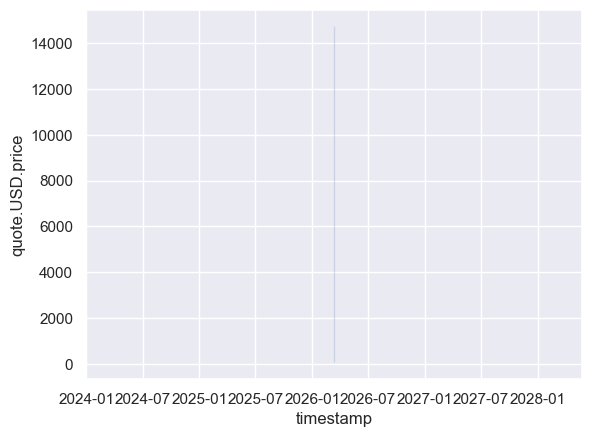

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='darkgrid')
sns.lineplot(x='timestamp', y='quote.USD.price', data=df2)

plt.show()